# Bài tập Machine Learning — Dự đoán bệnh tiểu đường

## Mục tiêu

1. Xây dựng **3 biểu đồ phân phối** từ `diabetes.csv`.
2. Xây dựng **5 mô hình học máy** cho bài toán phân loại.
3. Đánh giá 5 mô hình bằng **5 độ đo**: Accuracy, Precision, Recall, F1-score, ROC-AUC và chọn mô hình tốt nhất.
4. Với mô hình **K-Nearest Neighbors (KNN), chọn `k = 19`**.
5. Xuất mô hình tốt nhất để triển khai thành ứng dụng trên **điện thoại**.

### Phát biểu bài toán

Với các đặc trưng sức khỏe của một bệnh nhân:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

dự đoán biến `Outcome`:

- `0`: không mắc tiểu đường;
- `1`: mắc tiểu đường.

Đây là **bài toán phân loại nhị phân (Binary Classification)** vì biến mục tiêu `Outcome` chỉ có hai lớp 0 và 1.

### Luồng hệ thống

`Thông tin sức khỏe → Tiền xử lý → Mô hình ML → Xác suất / Nhãn dự đoán → Ứng dụng Mobile`


In [1]:
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


In [2]:
from IPython.display import display

DATA_PATH = r"C:\DATA\diabetes.csv"

df = pd.read_csv(DATA_PATH)

print("Kích thước dataset:", df.shape)
display(df.head())


Kích thước dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Khảo sát dữ liệu ban đầu

Dataset Diabetes thường gồm **8 đặc trưng đầu vào** và 1 biến mục tiêu `Outcome`.

Trong bộ dữ liệu Pima Indians Diabetes, một số cột có thể chứa giá trị `0` nhưng về mặt dữ liệu sức khỏe, `0` ở các cột sau thường được xem như giá trị thiếu:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Ta **không xóa toàn bộ các dòng này**. Thay vào đó:

1. đổi các giá trị `0` ở 5 cột trên thành `NaN`;
2. dùng `SimpleImputer(strategy="median")` để điền giá trị thiếu;
3. dùng `StandardScaler` để chuẩn hóa đặc trưng.

Các cột `Pregnancies`, `DiabetesPedigreeFunction`, `Age` không áp dụng quy tắc đổi `0 → NaN`.

`Outcome` là **target** và phải giữ nguyên 0/1.


In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique()
})
display(info)
display(df.describe(include="all").T)

print("\nPhân bố Outcome:")
display(df["Outcome"].value_counts().sort_index().to_frame("count"))
display(
    (df["Outcome"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame("percent")
)


,dtype,missing,missing_%,nunique
Pregnancies,int64,0,0.0,17
Glucose,int64,0,0.0,136
BloodPressure,int64,0,0.0,47
SkinThickness,int64,0,0.0,51
Insulin,int64,0,0.0,186
BMI,float64,0,0.0,248
DiabetesPedigreeFunction,float64,0,0.0,517
Age,int64,0,0.0,52
Outcome,int64,0,0.0,2


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Phân bố Outcome:


,count
Outcome,
0,500
1,268


,percent
Outcome,
0,65.1
1,34.9


## 2. Biểu diễn và làm sạch dữ liệu

Mỗi observation có thể biểu diễn dưới dạng vector:

\[
x =
[
Pregnancies,
Glucose,
BloodPressure,
SkinThickness,
Insulin,
BMI,
DiabetesPedigreeFunction,
Age
]
\]

Mô hình học một hàm:

\[
\hat{y} = f_\theta(x)
\]

trong đó:

- `x`: vector đặc trưng của một bệnh nhân;
- `fθ`: mô hình học máy;
- `ŷ`: nhãn dự đoán 0 hoặc 1.

Ta tạo một bản sao dữ liệu và thay các giá trị `0` không hợp lý bằng `NaN`. Việc điền median sẽ được thực hiện **bên trong pipeline** để tránh rò rỉ dữ liệu từ test sang train.


In [4]:
FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

TARGET = "Outcome"

ZERO_AS_MISSING = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"Dataset đang thiếu các cột cần thiết: {missing_columns}"
    )

df_model = df[required_columns].copy()

for col in ZERO_AS_MISSING:
    df_model[col] = df_model[col].replace(0, np.nan)

print("Số giá trị thiếu sau khi đổi 0 → NaN:")
display(df_model.isna().sum().to_frame("missing"))

display(df_model.head())


Số giá trị thiếu sau khi đổi 0 → NaN:


,missing
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# 3. Ba biểu đồ phân phối

Ba biểu đồ được chọn để nhìn nhanh cấu trúc dữ liệu:

1. Phân phối `Outcome` — số lượng người thuộc lớp 0 và lớp 1.
2. Phân phối `Glucose` — đặc trưng quan trọng liên quan trực tiếp tới đường huyết.
3. Phân phối `BMI` — cho biết phân bố chỉ số khối cơ thể.


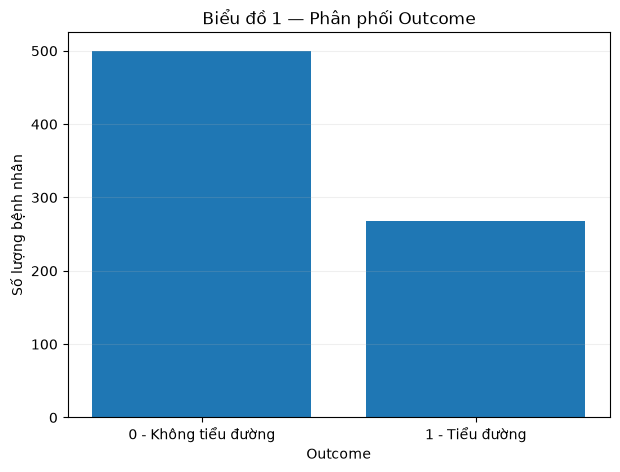

,count
Outcome,
0,500
1,268


In [5]:
# Biểu đồ 1: Phân phối Outcome
outcome_counts = df_model["Outcome"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["0 - Không tiểu đường", "1 - Tiểu đường"],
    outcome_counts.reindex([0, 1], fill_value=0).values
)
plt.title("Biểu đồ 1 — Phân phối Outcome")
plt.xlabel("Outcome")
plt.ylabel("Số lượng bệnh nhân")
plt.grid(axis="y", alpha=0.2)
plt.show()

display(outcome_counts.to_frame("count"))


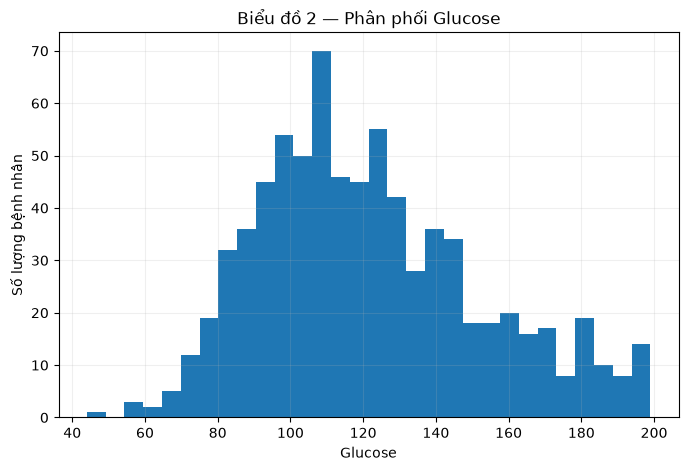

count    763.000000
mean     121.686763
std       30.535641
min       44.000000
25%       99.000000
50%      117.000000
75%      141.000000
max      199.000000
Name: Glucose, dtype: float64


In [6]:
# Biểu đồ 2: Phân phối Glucose
plt.figure(figsize=(8, 5))
plt.hist(df_model["Glucose"].dropna(), bins=30)
plt.title("Biểu đồ 2 — Phân phối Glucose")
plt.xlabel("Glucose")
plt.ylabel("Số lượng bệnh nhân")
plt.grid(alpha=0.2)
plt.show()

print(df_model["Glucose"].describe())


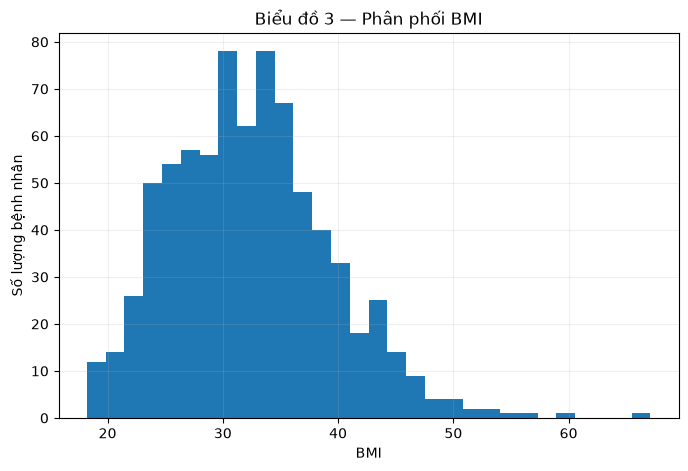

count    757.000000
mean      32.457464
std        6.924988
min       18.200000
25%       27.500000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64


In [7]:
# Biểu đồ 3: Phân phối BMI
plt.figure(figsize=(8, 5))
plt.hist(df_model["BMI"].dropna(), bins=30)
plt.title("Biểu đồ 3 — Phân phối BMI")
plt.xlabel("BMI")
plt.ylabel("Số lượng bệnh nhân")
plt.grid(alpha=0.2)
plt.show()

print(df_model["BMI"].describe())


# 4. Chuẩn bị dữ liệu huấn luyện

## Feature sử dụng

### Numerical
- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

Tất cả feature của dataset này đều là biến số nên không cần One-Hot Encoding.

## Tiền xử lý

- Các giá trị thiếu: `median imputation`
- Chuẩn hóa: `StandardScaler`
- Chia dữ liệu: **80% train / 20% test**
- Dùng `stratify=y` để tỷ lệ hai lớp trong train/test gần giống dataset gốc.
- `random_state = 42` để có thể tái lập kết quả.


In [8]:
X = df_model[FEATURES].copy()
y = df_model[TARGET].astype(int).copy()

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTỷ lệ lớp trong train:")
display(y_train.value_counts(normalize=True).sort_index().round(4))

print("Tỷ lệ lớp trong test:")
display(y_test.value_counts(normalize=True).sort_index().round(4))


Train: (614, 8)
Test : (154, 8)

Tỷ lệ lớp trong train:


Outcome
0    0.6515
1    0.3485
Name: proportion, dtype: float64

Tỷ lệ lớp trong test:


Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64

## Baseline

Baseline không được tính vào 5 mô hình chính. Nó chỉ là mốc tham chiếu để kiểm tra xem các mô hình học được có thực sự tốt hơn chiến lược đơn giản hay không.

Ở đây dùng `DummyClassifier(strategy="most_frequent")`: luôn dự đoán lớp xuất hiện nhiều nhất trong tập train.


In [9]:
baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

# DummyClassifier có predict_proba nên có thể tính ROC-AUC.
baseline_prob = baseline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob),
}

display(pd.DataFrame([baseline_metrics], index=["Baseline"]).round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.6494,0.0,0.0,0.0,0.5


# 5. Xây dựng 5 mô hình học máy

Năm mô hình:

1. **Logistic Regression**
2. **K-Nearest Neighbors Classifier — `k = 19`**
3. **Decision Tree Classifier**
4. **Random Forest Classifier**
5. **Support Vector Machine — RBF Kernel**

> Theo yêu cầu bài này, KNN được cố định **`n_neighbors = 19`**.

Các mô hình được đánh giá trên **cùng train/test split** và cùng pipeline tiền xử lý để so sánh công bằng.


In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    # Theo yêu cầu: KNN chọn k = 19
    "KNN (k=19)": KNeighborsClassifier(
        n_neighbors=19,
        weights="uniform",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ),
}

print("K của KNN:", models["KNN (k=19)"].n_neighbors)


K của KNN: 19


In [11]:
results = []
trained_models = {}

for name, estimator in models.items():
    start = time.time()

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "Training + prediction time (s)": time.time() - start,
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by=["F1", "ROC-AUC", "Recall"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training + prediction time (s)
0,Decision Tree,0.7727,0.6508,0.7593,0.7009,0.7992,0.0645
1,Random Forest,0.7662,0.7045,0.5741,0.6327,0.8170,0.6559
2,KNN (k=19),0.7468,0.6667,0.5556,0.6061,0.8077,0.1546
3,SVM RBF,0.7403,0.6522,0.5556,0.6000,0.7964,0.0989
4,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130,0.0573


# 6. Đánh giá bằng 5 độ đo

Vì đây là bài toán phân loại nhị phân nên sử dụng:

- **Accuracy**: tỷ lệ dự đoán đúng trên toàn bộ mẫu — càng lớn càng tốt.
- **Precision**: trong các mẫu được dự đoán là tiểu đường, có bao nhiêu mẫu thực sự là tiểu đường — càng lớn càng tốt.
- **Recall**: trong các bệnh nhân thực sự tiểu đường, mô hình phát hiện được bao nhiêu — càng lớn càng tốt.
- **F1-score**: trung bình điều hòa của Precision và Recall — càng lớn càng tốt.
- **ROC-AUC**: khả năng mô hình phân biệt hai lớp ở nhiều threshold khác nhau — càng gần 1 càng tốt.

Trong notebook này, **F1-score được dùng làm tiêu chí chính** để xếp hạng vì dữ liệu có thể không cân bằng hoàn toàn giữa lớp 0 và lớp 1. Sau đó kiểm tra thêm ROC-AUC và Recall.


Mô hình tốt nhất theo F1-score: Decision Tree


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training + prediction time (s)
0,Decision Tree,0.7727,0.6508,0.7593,0.7009,0.7992,0.0645


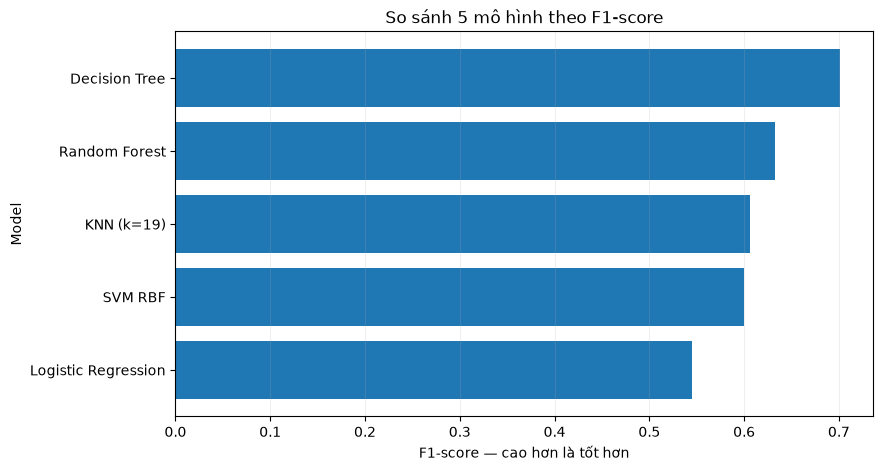

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Mô hình tốt nhất theo F1-score:", best_model_name)
display(results_df.iloc[[0]].round(4))

# Bảng xếp hạng trực quan theo F1-score
ranking = results_df.sort_values("F1", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(ranking["Model"], ranking["F1"])
plt.title("So sánh 5 mô hình theo F1-score")
plt.xlabel("F1-score — cao hơn là tốt hơn")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.2)
plt.show()


## Kết luận thực nghiệm

Mô hình tốt nhất **không được chọn trước theo tên thuật toán** mà được xác định từ kết quả chạy thực tế trên tập test.

Notebook tự động:

1. huấn luyện cả 5 mô hình;
2. tính Accuracy, Precision, Recall, F1 và ROC-AUC;
3. sắp xếp theo **F1-score**;
4. nếu F1 gần nhau, kiểm tra tiếp **ROC-AUC** và **Recall**.

Riêng KNN được giữ cố định **`k = 19`** đúng theo yêu cầu.

Khi viết báo cáo, cần lấy **kết quả thực tế từ `results_df` sau khi chạy notebook** để kết luận mô hình nào tốt nhất, thay vì ghi cứng tên mô hình trước khi có số liệu.


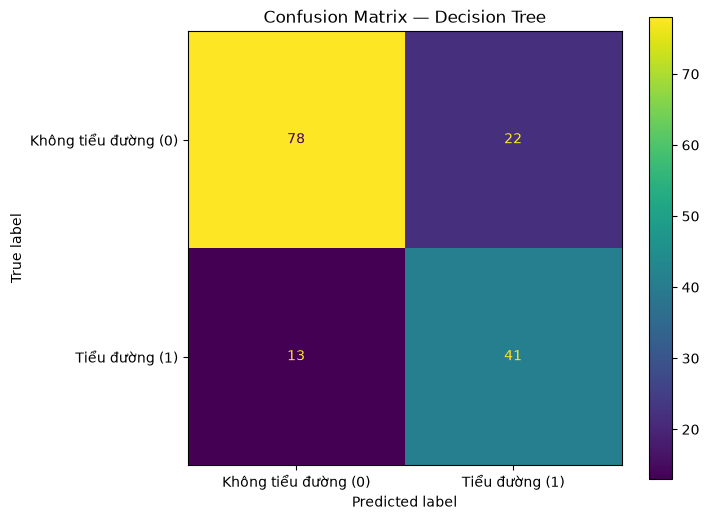

True Negative : 78
False Positive: 22
False Negative: 13
True Positive : 41


In [13]:
# Confusion Matrix của mô hình tốt nhất
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Không tiểu đường (0)", "Tiểu đường (1)"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.grid(False)
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)


# 7. Xuất mô hình tốt nhất

Ta lưu **toàn bộ pipeline**, không chỉ riêng classifier.

Điều này rất quan trọng vì khi ứng dụng Mobile gửi dữ liệu mới, dữ liệu đó phải đi qua đúng:

`Median Imputation → StandardScaler → Classifier`

giống hệt lúc training.


In [ ]:
MODEL_PATH = Path("diabetes.sav")
joblib.dump(best_model, MODEL_PATH)

print("Mô hình tốt nhất:", best_model_name)
print("Đã lưu:", MODEL_PATH.resolve())


Mô hình tốt nhất: Decision Tree
Đã lưu: C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\best_diabetes_model.sav


# 8. Triển khai trên Mobilephone

## Kiến trúc được chọn

Với mô hình Scikit-learn, cách dễ triển khai và dễ demo nhất là:

```text
Mobile App (React Native / Expo)
        |
        | HTTP POST /predict
        v
FastAPI inference service
        |
        v
best_diabetes_model.sav
        |
        v
Prediction JSON
        |
        v
Mobile hiển thị:
- Outcome dự đoán: 0 / 1
- Xác suất dự đoán
```

### Input gửi từ Mobile

Ví dụ:

```json
{
  "Pregnancies": 2,
  "Glucose": 120,
  "BloodPressure": 70,
  "SkinThickness": 25,
  "Insulin": 90,
  "BMI": 28.5,
  "DiabetesPedigreeFunction": 0.45,
  "Age": 35
}
```

### Vì sao dùng API thay vì chạy `.sav` trực tiếp trên điện thoại?

File `.sav` chứa pipeline Python/Scikit-learn và không thể được React Native chạy trực tiếp. Đặt mô hình trong một inference service giúp:

- giữ nguyên pipeline Python đã kiểm chứng;
- Mobile chỉ cần gửi JSON và nhận kết quả;
- dễ thay model mà không cần build lại app;
- thuận tiện khi demo trên điện thoại thật.

Nếu yêu cầu là **offline/on-device inference**, có thể chuyển mô hình sang ONNX sau.


# 9. Tổng kết

Đã hoàn thành:

- đọc và khảo sát `diabetes.csv`;
- xử lý các giá trị `0` không hợp lý thành missing value;
- median imputation + StandardScaler trong pipeline;
- 3 biểu đồ phân phối;
- baseline;
- 5 mô hình phân loại;
- **KNN với `k = 19`**;
- 5 chỉ số đánh giá: Accuracy, Precision, Recall, F1, ROC-AUC;
- chọn mô hình tốt nhất dựa trên F1-score và số liệu thực nghiệm;
- Confusion Matrix cho mô hình tốt nhất;
- lưu toàn bộ pipeline thành `best_diabetes_model.sav`;
- chuẩn bị kiến trúc triển khai Mobile qua FastAPI.

> Khi viết báo cáo, cần chạy notebook trên đúng dataset rồi lấy số liệu trong `results_df` để kết luận. Không nên ghi cứng mô hình tốt nhất khi chưa chạy dữ liệu thực tế.
